In [ ]:
!pip install torch torchvision torchaudio
!pip install matplotlib numpy pillow tqdm


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.utils import save_image
from PIL import Image
import os
from tqdm import tqdm
import torchvision.transforms as transforms
import torch.nn.functional as F
import matplotlib.pyplot as plt





In [ ]:
!pip install kagglehub
import kagglehub


In [ ]:
path = kagglehub.dataset_download("ktaebum/anime-sketch-colorization-pair")
print("Dataset downloaded to:", path)

print("\nTop-level contents:")
print(os.listdir(path))



100%|██████████| 11.6G/11.6G [08:45<00:00, 23.8MB/s]

Extracting files...


Dataset downloaded to: /root/.cache/kagglehub/datasets/ktaebum/anime-sketch-colorization-pair/versions/1

Top-level contents:
['data']


In [ ]:
class Sketch2ColorDataset(Dataset):
    def __init__(self, folder, img_size=128):
        self.folder = folder
        self.files = sorted(os.listdir(folder))
        self.img_size = img_size

        # Transform for sketch (1 channel)
        self.transform_sketch = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5], [0.5])  # [-1,1]
        ])

        # Transform for color image (3 channels)
        self.transform_color = transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize([0.5,0.5,0.5], [0.5,0.5,0.5])  # [-1,1]
        ])

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
      path = os.path.join(self.folder, self.files[idx])
      img = Image.open(path).convert("RGB")
      w, h = img.size

      # LEFT = color, RIGHT = sketch
      color  = img.crop((0, 0, w//2, h))
      sketch = img.crop((w//2, 0, w, h)).convert("L")  # convert to grayscale

      sketch = self.transform_sketch(sketch)  # shape [1,H,W]
      color  = self.transform_color(color)    # shape [3,H,W]

      return sketch, color, self.files[idx]


In [ ]:
train_folder = "/root/.cache/kagglehub/datasets/ktaebum/anime-sketch-colorization-pair/versions/1/data/train"
val_folder   = "/root/.cache/kagglehub/datasets/ktaebum/anime-sketch-colorization-pair/versions/1/data/val"

train_ds = Sketch2ColorDataset(train_folder, img_size=128)
val_ds   = Sketch2ColorDataset(val_folder, img_size=128)

from torch.utils.data import DataLoader

train_loader = DataLoader(train_ds, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_ds, batch_size=1, shuffle=False)


In [ ]:
# Generator
class UNetGenerator(nn.Module):
    def __init__(self, in_channels=1, out_channels=3, features=64):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels, features, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=False),
            nn.Conv2d(features, features*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features*2),
            nn.LeakyReLU(0.2, inplace=False),
            nn.Conv2d(features*2, features*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features*4),
            nn.LeakyReLU(0.2, inplace=False),
            )
        self.middle = nn.Sequential(
            nn.Conv2d(features*4, features*8, 4, 2, 1, bias=False),
            nn.ReLU(inplace=False)
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(features*8, features*4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features*4),
            nn.ReLU(inplace=False),
            nn.ConvTranspose2d(features*4, features*2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features*2),
            nn.ReLU(inplace=False),
            nn.ConvTranspose2d(features*2, out_channels, 4, 2, 1),
            nn.Tanh()
        )

    def forward(self, x):
        x1 = self.encoder(x)
        x2 = self.middle(x1)
        out = self.decoder(x2)
        return out

# Discriminator
class PatchDiscriminator(nn.Module):
    def __init__(self, in_channels=4, features=64):
        super().__init__()
        self.model = nn.Sequential(
            nn.Conv2d(in_channels, features, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=False),
            nn.Conv2d(features, features*2, 4, 2, 1),
            nn.BatchNorm2d(features*2),
            nn.LeakyReLU(0.2, inplace=False),
            nn.Conv2d(features*2, features*4, 4, 2, 1),
            nn.BatchNorm2d(features*4),
            nn.LeakyReLU(0.2, inplace=False),
            nn.Conv2d(features*4, 1, 4, 1, 1)
        )

    def forward(self, sketch, color):
        x = torch.cat([sketch, color], dim=1)
        return self.model(x)


Using device: cuda


Epoch [1/5]: 100%|██████████| 1778/1778 [05:19<00:00,  5.57it/s, d_loss=0.000849, g_loss=28.9]


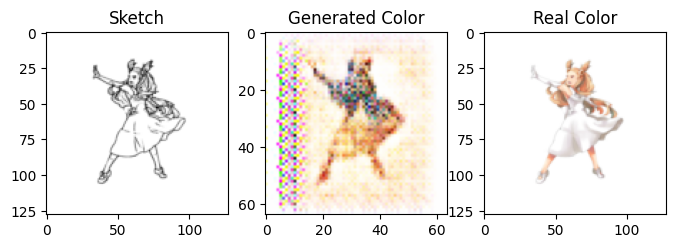

Epoch [2/5]: 100%|██████████| 1778/1778 [05:04<00:00,  5.84it/s, d_loss=0.00019, g_loss=28.7]


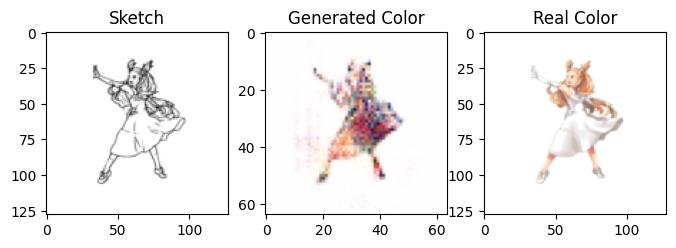

Epoch [3/5]: 100%|██████████| 1778/1778 [05:02<00:00,  5.87it/s, d_loss=3.32e-5, g_loss=27.5]


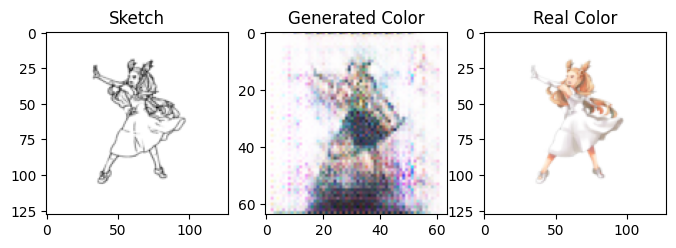

Epoch [4/5]: 100%|██████████| 1778/1778 [05:08<00:00,  5.77it/s, d_loss=9.63e-6, g_loss=27.3]


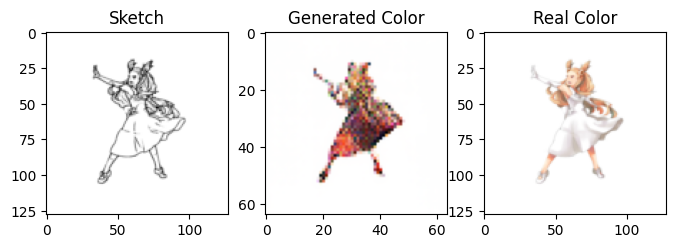

Epoch [5/5]: 100%|██████████| 1778/1778 [05:09<00:00,  5.74it/s, d_loss=1.11e-5, g_loss=31.7]


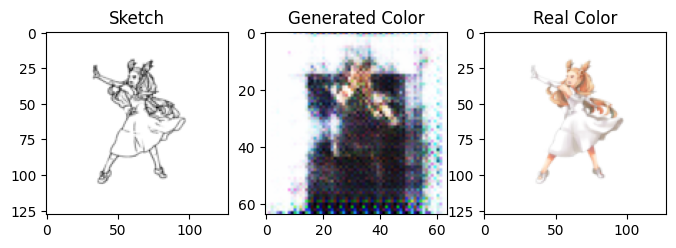

In [ ]:
# =========================================
# STEP 7: Define loss functions and optimizers
# =========================================

torch.autograd.set_detect_anomaly(True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

gen  = UNetGenerator().to(device)
disc = PatchDiscriminator().to(device)

g_opt = optim.Adam(gen.parameters(), lr=2e-4, betas=(0.5,0.999))
d_opt = optim.Adam(disc.parameters(), lr=2e-4, betas=(0.5,0.999))

adv_criterion = nn.BCEWithLogitsLoss()
l1_criterion  = nn.L1Loss()
lambda_L1 = 100.0

# =========================================
# STEP 8: Training Loop
# =========================================
EPOCHS = 5  # change as needed

for epoch in range(EPOCHS):
    gen.train()
    disc.train()
    loop = tqdm(train_loader, leave=True)
    for sketches, colors, _ in loop:
        sketches = sketches.to(device)
        colors = colors.to(device)

       # Generate fake colors
        fake_colors = gen(sketches).contiguous()

        # Resize for discriminator
        fake_colors_resized = F.interpolate(fake_colors, size=sketches.shape[2:], mode='bilinear', align_corners=False)

        # Discriminator
        d_real = disc(sketches, colors)
        d_fake = disc(sketches, fake_colors_resized.detach())

        real_labels = torch.ones_like(d_real).to(device)
        fake_labels = torch.zeros_like(d_fake).to(device)

        d_loss_real = adv_criterion(d_real, real_labels)
        d_loss_fake = adv_criterion(d_fake, fake_labels)
        d_loss = (d_loss_real + d_loss_fake) / 2

        d_opt.zero_grad()
        d_loss.backward()
        d_opt.step()

        # Generator
        g_fake = disc(sketches, fake_colors_resized)
        g_loss_adv = adv_criterion(g_fake, real_labels)
        g_loss_l1  = l1_criterion(fake_colors_resized, colors) * lambda_L1
        g_loss = g_loss_adv + g_loss_l1

        g_opt.zero_grad()
        g_loss.backward()
        g_opt.step()


        loop.set_description(f"Epoch [{epoch+1}/{EPOCHS}]")
        loop.set_postfix(d_loss=d_loss.item(), g_loss=g_loss.item())

    # Preview results
    gen.eval()
    with torch.no_grad():
        sketches, colors, names = next(iter(val_loader))
        sketches = sketches.to(device)
        fake_colors = gen(sketches).cpu()
        plt.figure(figsize=(8,4))
        plt.subplot(1,3,1)
        plt.imshow(sketches[0][0].cpu()*0.5+0.5, cmap='gray')
        plt.title("Sketch")
        plt.subplot(1,3,2)
        plt.imshow(fake_colors[0].permute(1,2,0)*0.5+0.5)
        plt.title("Generated Color")
        plt.subplot(1,3,3)
        plt.imshow(colors[0].permute(1,2,0)*0.5+0.5)
        plt.title("Real Color")
        plt.show()


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

MessageError: Error: credential propagation was unsuccessful

In [ ]:
import torch

# Save generator and discriminator weights
torch.save(gen.state_dict(), "generator_model.h5")
torch.save(disc.state_dict(), "discriminator_model.h5")

print("✅ Models saved as 'generator_model.h5' and 'discriminator_model.h5'")


✅ Models saved as 'generator_model.h5' and 'discriminator_model.h5'


In [ ]:
gen = UNetGenerator()
disc = PatchDiscriminator()

gen.eval()

UNetGenerator(
  (encoder): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): LeakyReLU(negative_slope=0.2)
    (2): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2)
    (5): Conv2d(128, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (6): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2)
  )
  (middle): Sequential(
    (0): Conv2d(256, 512, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): ConvTranspose2d(256, 128,

In [ ]:
# Ensure model and data are on same device
device = "cuda" if torch.cuda.is_available() else "cpu"
gen = gen.to(device)

gen.eval()
val_results = []

with torch.no_grad():
    for sketches, colors, _ in tqdm(val_loader, desc="Validating"):
        sketches, colors = sketches.to(device), colors.to(device)
        fake_colors = gen(sketches)

        val_results.append((sketches.cpu(), colors.cpu(), fake_colors.cpu()))


Validating: 100%|██████████| 3545/3545 [00:56<00:00, 62.57it/s]


In [ ]:
import torch
from tqdm import tqdm

# Make sure the model and data are on the same device
device = "cuda" if torch.cuda.is_available() else "cpu"
print("✅ Using device:", device)

# Move model to GPU (important!)
gen = gen.to(device)

# Evaluation mode (disables dropout, batchnorm updates)
gen.eval()

val_results = []

# Validation loop
with torch.no_grad():
    for sketches, colors, _ in tqdm(val_loader, desc="Validating"):
        # Move input data to GPU
        sketches, colors = sketches.to(device), colors.to(device)

        # Forward pass (generate color images)
        fake_colors = gen(sketches)

        # Store results (move back to CPU for metrics)
        val_results.append((sketches.cpu(), colors.cpu(), fake_colors.cpu()))

print("✅ Validation completed successfully.")


✅ Using device: cuda


Validating: 100%|██████████| 3545/3545 [00:51<00:00, 69.33it/s]

✅ Validation completed successfully.


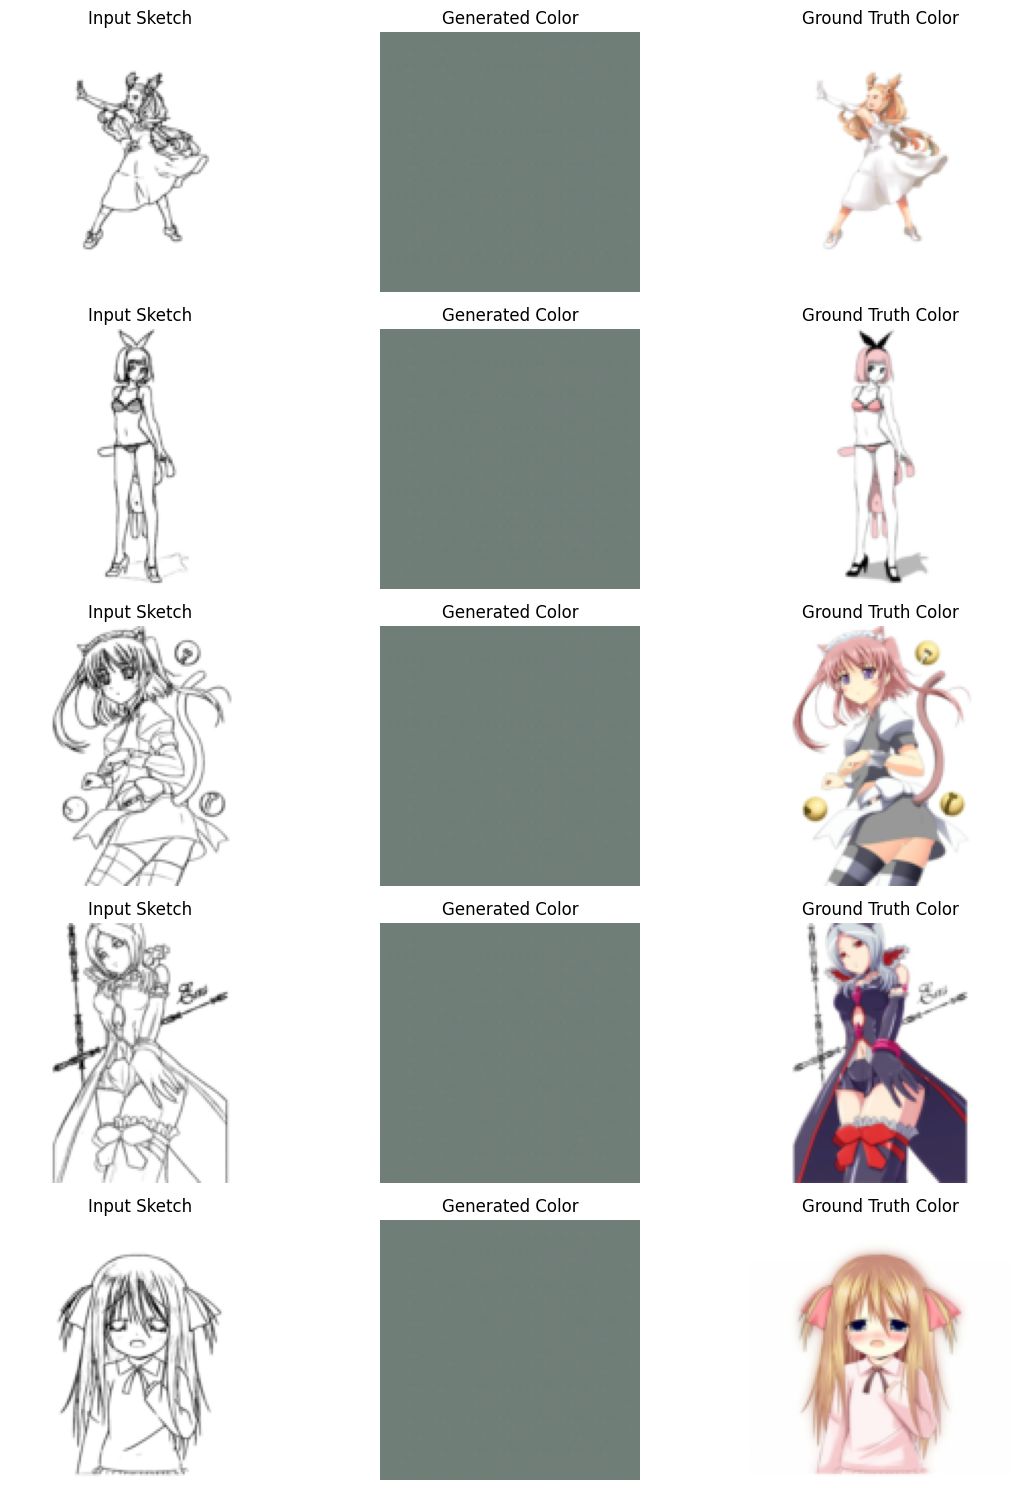

In [ ]:
import matplotlib.pyplot as plt

# Make sure we have results
if len(val_results) == 0:
    print("⚠️ No validation results found. Make sure you ran the validation loop first.")
else:
    # Show a few random examples
    num_examples = 5  # change this to see more results
    plt.figure(figsize=(12, num_examples * 3))

    for i in range(num_examples):
        sketches, colors, fakes = val_results[i]

        # Denormalize images from [-1,1] → [0,1]
        sketch = sketches[0][0].numpy() * 0.5 + 0.5
        fake = fakes[0].permute(1, 2, 0).numpy() * 0.5 + 0.5
        real = colors[0].permute(1, 2, 0).numpy() * 0.5 + 0.5

        # Display sketch
        plt.subplot(num_examples, 3, 3*i + 1)
        plt.imshow(sketch, cmap='gray')
        plt.title("Input Sketch")
        plt.axis("off")

        # Display generated color image
        plt.subplot(num_examples, 3, 3*i + 2)
        plt.imshow(fake)
        plt.title("Generated Color")
        plt.axis("off")

        # Display ground truth color
        plt.subplot(num_examples, 3, 3*i + 3)
        plt.imshow(real)
        plt.title("Ground Truth Color")
        plt.axis("off")

    plt.tight_layout()
    plt.show()


In [ ]:
train_g_losses = []
train_d_losses = []
val_l1_losses = []


In [ ]:
# =========================================
# STEP 7: Define loss functions and optimizers
# =========================================

device = "cuda" if torch.cuda.is_available() else "cpu"
print("✅ Using device:", device)

# move both models to GPU
gen  = UNetGenerator().to(device)
disc = PatchDiscriminator().to(device)

# optimizers (with balanced learning rates)
g_opt = optim.Adam(gen.parameters(), lr=2e-4, betas=(0.5, 0.999))
d_opt = optim.Adam(disc.parameters(), lr=1e-4, betas=(0.5, 0.999))

adv_criterion = nn.BCEWithLogitsLoss()
l1_criterion  = nn.L1Loss()
lambda_L1 = 100.0


✅ Using device: cuda


In [ ]:
import os
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch.nn.functional as F

# Directory to save visual validation results
os.makedirs("validation_results", exist_ok=True)

EPOCHS = 20  # You can adjust
train_g_losses, train_d_losses, val_l1_losses = [], [], []

for epoch in range(EPOCHS):
    gen.train()
    disc.train()
    epoch_g_loss, epoch_d_loss = 0.0, 0.0
    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{EPOCHS}]")

    # ---------------------
    # TRAINING PHASE
    # ---------------------
    for sketches, colors, _ in loop:
        sketches, colors = sketches.to(device), colors.to(device)

        # --- Train Discriminator ---
        fake_colors = gen(sketches)
        fake_colors_resized = F.interpolate(fake_colors, size=sketches.shape[2:], mode='bilinear', align_corners=False)

        d_real = disc(sketches, colors)
        d_fake = disc(sketches, fake_colors_resized.detach())

        real_labels = torch.ones_like(d_real, device=device)
        fake_labels = torch.zeros_like(d_fake, device=device)

        d_loss_real = adv_criterion(d_real, real_labels)
        d_loss_fake = adv_criterion(d_fake, fake_labels)
        d_loss = (d_loss_real + d_loss_fake) / 2

        d_opt.zero_grad()
        d_loss.backward()
        d_opt.step()

        # --- Train Generator ---
        g_fake = disc(sketches, fake_colors_resized)
        g_loss_adv = adv_criterion(g_fake, real_labels)
        g_loss_l1 = l1_criterion(fake_colors_resized, colors) * lambda_L1
        g_loss = g_loss_adv + g_loss_l1

        g_opt.zero_grad()
        g_loss.backward()
        g_opt.step()

        epoch_d_loss += d_loss.item()
        epoch_g_loss += g_loss.item()
        loop.set_postfix(d_loss=d_loss.item(), g_loss=g_loss.item())

    # ---------------------
    #  VALIDATION PHASE
    # ---------------------
gen.eval()
val_l1_loss = 0.0
with torch.no_grad():
    for sketches, colors, _ in val_loader:
        sketches, colors = sketches.to(device), colors.to(device)
        fake_colors = gen(sketches)

        # ✅ Ensure same size before computing loss
        fake_colors_resized = F.interpolate(fake_colors, size=colors.shape[2:], mode='bilinear', align_corners=False)

        val_l1_loss += l1_criterion(fake_colors_resized, colors).item()



    avg_d_loss = epoch_d_loss / len(train_loader)
    avg_g_loss = epoch_g_loss / len(train_loader)
    avg_val_l1 = val_l1_loss / len(val_loader)

    train_d_losses.append(avg_d_loss)
    train_g_losses.append(avg_g_loss)
    val_l1_losses.append(avg_val_l1)

    print(f"\n✅ Epoch [{epoch+1}/{EPOCHS}] completed | D_Loss: {avg_d_loss:.5f} | G_Loss: {avg_g_loss:.5f} | Val_L1: {avg_val_l1:.5f}")

    # ---------------------
    # SAVE CHECKPOINTS EVERY 10 EPOCHS
    # ---------------------
    if (epoch + 1) % 10 == 0:
        torch.save(gen.state_dict(), f"generator_epoch_{epoch+1}.pth")
        torch.save(disc.state_dict(), f"discriminator_epoch_{epoch+1}.pth")
        print(f"💾 Checkpoints saved at epoch {epoch+1}")

# ---------------------
# VALIDATION VISUALIZATION (show multiple samples)
# ---------------------
with torch.no_grad():
    sketches, colors, _ = next(iter(val_loader))
    sketches = sketches.to(device)
    fake_colors = gen(sketches).cpu()

    num_samples = min(4, sketches.shape[0])  # show up to 4 examples
    plt.figure(figsize=(12, num_samples * 3))

    for i in range(num_samples):
        # Sketch
        plt.subplot(num_samples, 3, 3*i + 1)
        plt.imshow(sketches[i][0].cpu() * 0.5 + 0.5, cmap='gray')
        plt.title("Sketch")
        plt.axis("off")

        # Generated color
        plt.subplot(num_samples, 3, 3*i + 2)
        plt.imshow(fake_colors[i].permute(1, 2, 0) * 0.5 + 0.5)
        plt.title("Generated")
        plt.axis("off")

        # Real color
        plt.subplot(num_samples, 3, 3*i + 3)
        plt.imshow(colors[i].permute(1, 2, 0).cpu() * 0.5 + 0.5)
        plt.title("Ground Truth")
        plt.axis("off")

    plt.suptitle(f"Validation Results - Epoch {epoch+1}", fontsize=12)
    plt.tight_layout()
    plt.savefig(f"validation_results/val_result_epoch_{epoch+1}.png")
    plt.show()
    print(f"🖼️ Saved validation preview: validation_results/val_result_epoch_{epoch+1}.png")



Epoch [7/20]:  37%|███▋      | 654/1778 [01:43<02:57,  6.32it/s, d_loss=7.04e-5, g_loss=25.9]


KeyboardInterrupt: 

✅ Using device: cuda


Epoch [1/20]: 100%|██████████| 1778/1778 [04:49<00:00,  6.15it/s, d_loss=0.00069, g_loss=28.1]



✅ Epoch [1/20] completed | D_Loss: 0.085617 | G_Loss: 26.208617 | Val_L1: 0.226530


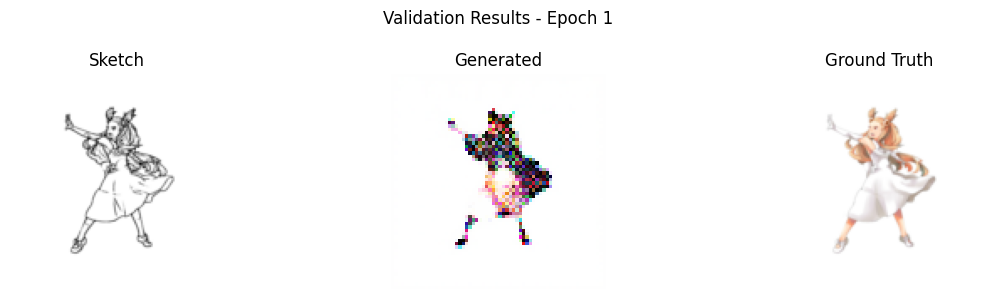

Epoch [2/20]: 100%|██████████| 1778/1778 [04:45<00:00,  6.24it/s, d_loss=0.000268, g_loss=23.3]



✅ Epoch [2/20] completed | D_Loss: 0.000505 | G_Loss: 27.182568 | Val_L1: 0.201811


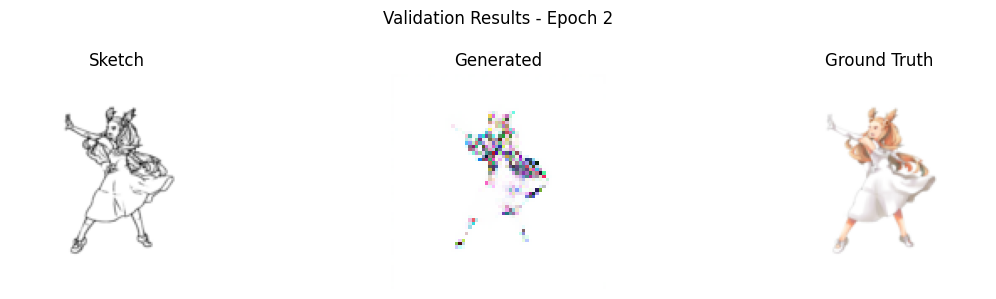

Epoch [3/20]: 100%|██████████| 1778/1778 [04:45<00:00,  6.22it/s, d_loss=6.58e-5, g_loss=28.6]



✅ Epoch [3/20] completed | D_Loss: 0.000103 | G_Loss: 27.757949 | Val_L1: 0.270137


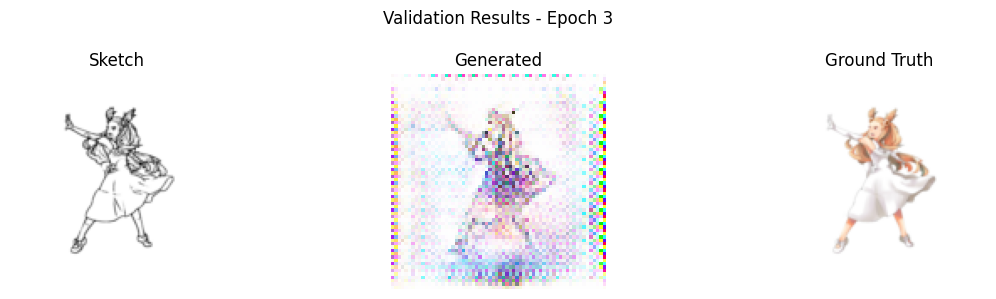

Epoch [4/20]: 100%|██████████| 1778/1778 [04:52<00:00,  6.07it/s, d_loss=0.0209, g_loss=23]



✅ Epoch [4/20] completed | D_Loss: 0.036452 | G_Loss: 27.195055 | Val_L1: 0.194421


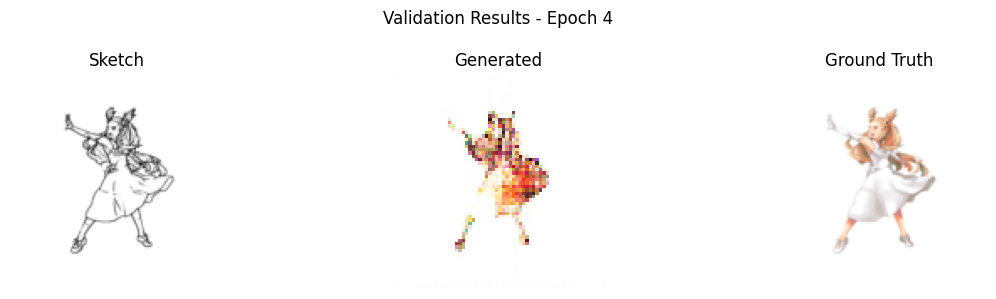

Epoch [5/20]: 100%|██████████| 1778/1778 [04:50<00:00,  6.12it/s, d_loss=0.000177, g_loss=28.4]



✅ Epoch [5/20] completed | D_Loss: 0.004436 | G_Loss: 23.699909 | Val_L1: 0.642012


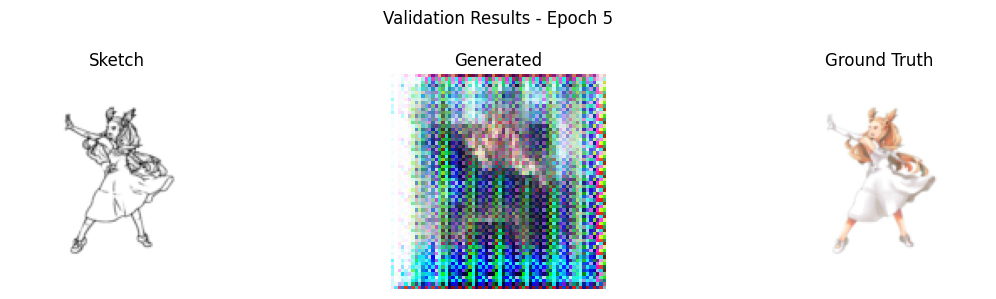

Epoch [6/20]: 100%|██████████| 1778/1778 [04:53<00:00,  6.06it/s, d_loss=7.89e-5, g_loss=25.9]



✅ Epoch [6/20] completed | D_Loss: 0.000110 | G_Loss: 24.871521 | Val_L1: 0.174321


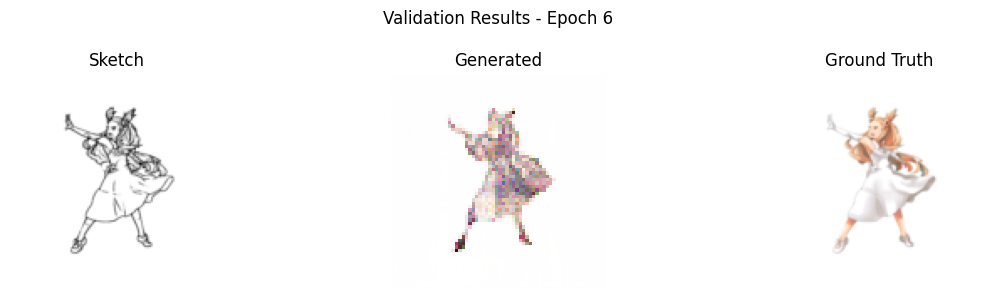

Epoch [7/20]: 100%|██████████| 1778/1778 [04:56<00:00,  5.99it/s, d_loss=1.17e-5, g_loss=29.8]



✅ Epoch [7/20] completed | D_Loss: 0.000036 | G_Loss: 25.213842 | Val_L1: 0.174069


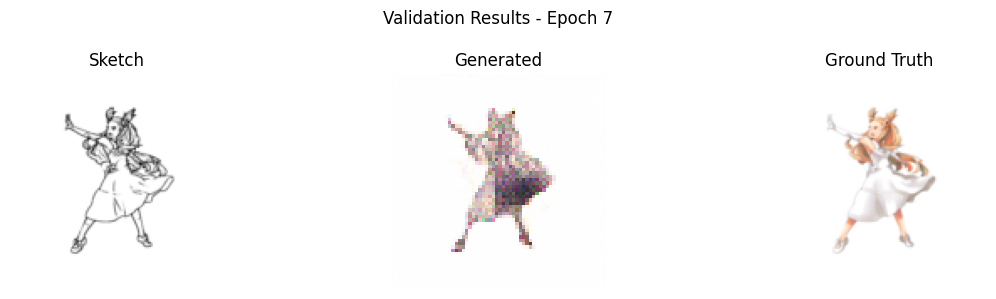

Epoch [8/20]: 100%|██████████| 1778/1778 [04:58<00:00,  5.95it/s, d_loss=0.000512, g_loss=21.9]



✅ Epoch [8/20] completed | D_Loss: 0.008790 | G_Loss: 24.293738 | Val_L1: 0.175403


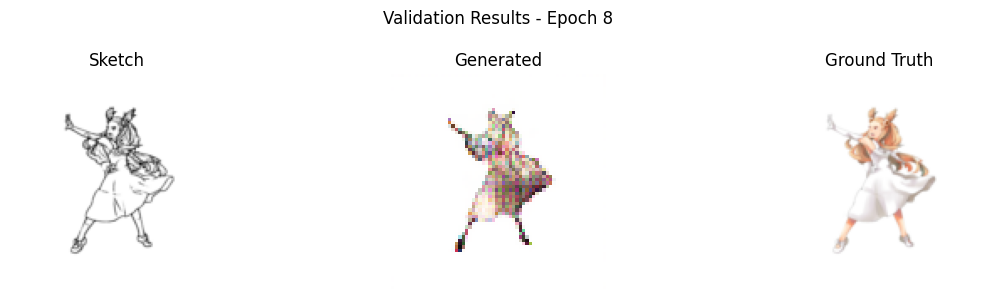

Epoch [9/20]: 100%|██████████| 1778/1778 [04:56<00:00,  5.99it/s, d_loss=4.23e-5, g_loss=22.1]



✅ Epoch [9/20] completed | D_Loss: 0.000164 | G_Loss: 22.716746 | Val_L1: 0.204679


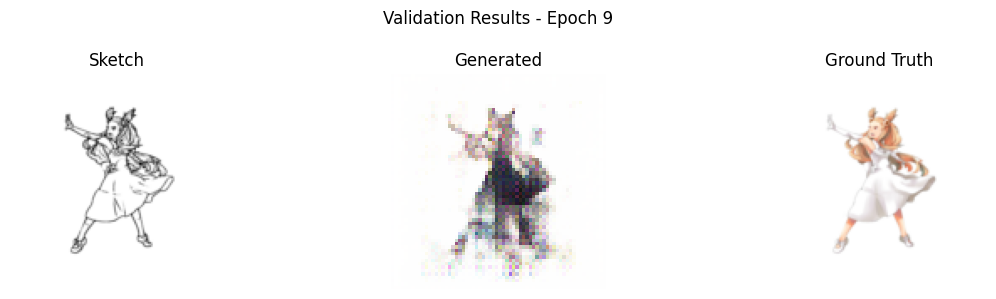

Epoch [10/20]: 100%|██████████| 1778/1778 [05:00<00:00,  5.91it/s, d_loss=1.49e-5, g_loss=26]



✅ Epoch [10/20] completed | D_Loss: 0.000034 | G_Loss: 23.512241 | Val_L1: 0.197333
💾 Checkpoints saved for epoch 10


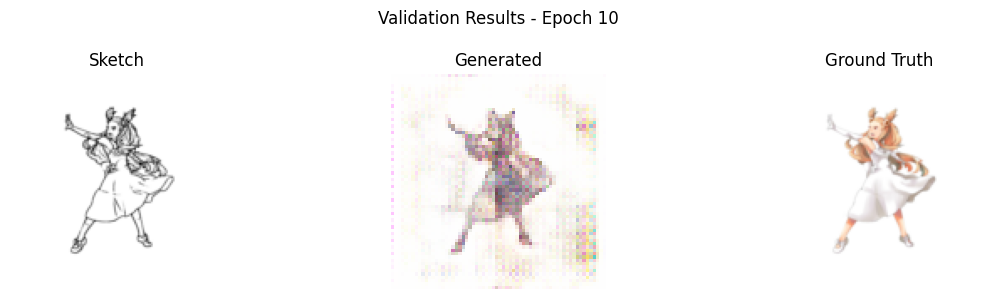

Epoch [11/20]: 100%|██████████| 1778/1778 [05:02<00:00,  5.87it/s, d_loss=6.7e-6, g_loss=21.7]



✅ Epoch [11/20] completed | D_Loss: 0.000011 | G_Loss: 23.947062 | Val_L1: 0.173966


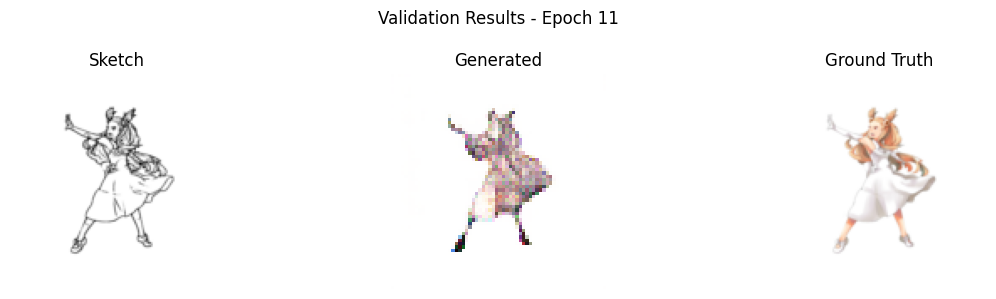

Epoch [12/20]: 100%|██████████| 1778/1778 [05:01<00:00,  5.90it/s, d_loss=3.15e-6, g_loss=25.5]



✅ Epoch [12/20] completed | D_Loss: 0.000005 | G_Loss: 24.354290 | Val_L1: 0.173462


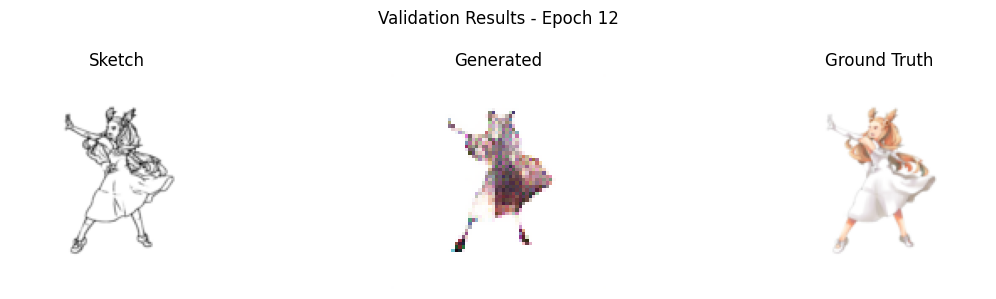

Epoch [13/20]: 100%|██████████| 1778/1778 [05:03<00:00,  5.87it/s, d_loss=8.68e-7, g_loss=26.7]



✅ Epoch [13/20] completed | D_Loss: 0.000002 | G_Loss: 24.824896 | Val_L1: 0.176409


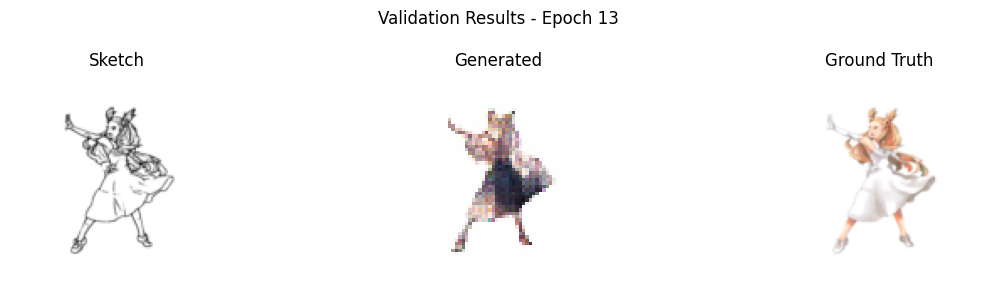

Epoch [14/20]: 100%|██████████| 1778/1778 [05:07<00:00,  5.78it/s, d_loss=3.21e-7, g_loss=26.2]



✅ Epoch [14/20] completed | D_Loss: 0.000001 | G_Loss: 25.312338 | Val_L1: 0.209289


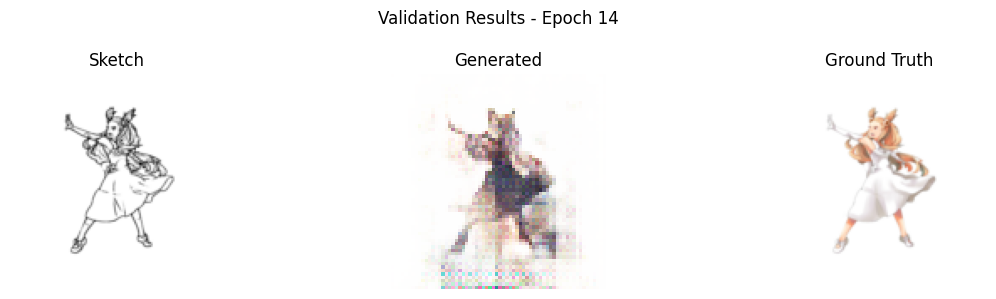

Epoch [15/20]: 100%|██████████| 1778/1778 [05:11<00:00,  5.70it/s, d_loss=1.32e-7, g_loss=25.6]



✅ Epoch [15/20] completed | D_Loss: 0.000000 | G_Loss: 25.854647 | Val_L1: 0.176733


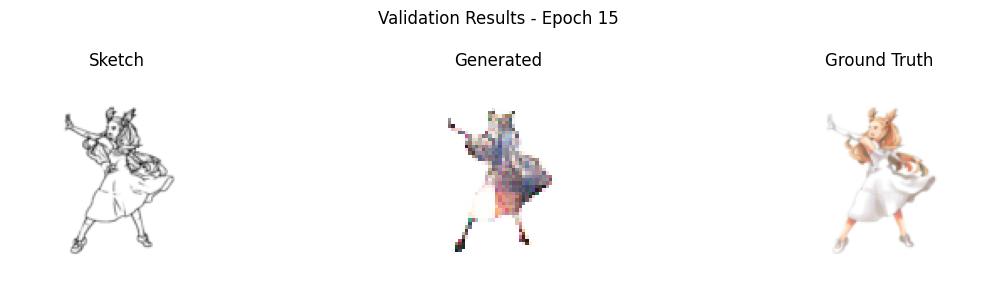

Epoch [16/20]: 100%|██████████| 1778/1778 [05:11<00:00,  5.71it/s, d_loss=4.91e-8, g_loss=29.9]



✅ Epoch [16/20] completed | D_Loss: 0.000000 | G_Loss: 26.452484 | Val_L1: 0.171294


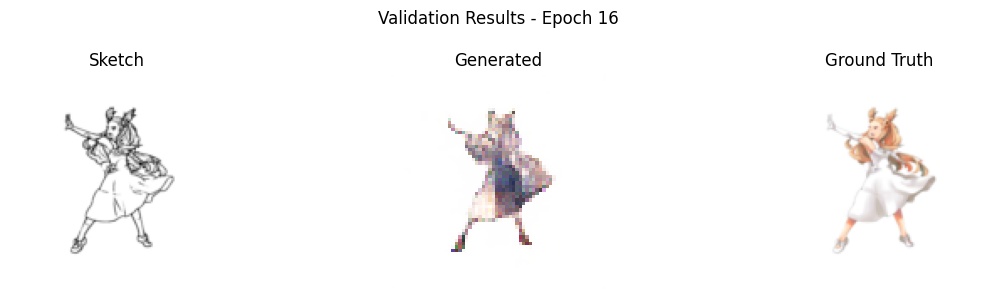

Epoch [17/20]: 100%|██████████| 1778/1778 [05:15<00:00,  5.64it/s, d_loss=1.49e-8, g_loss=30.7]



✅ Epoch [17/20] completed | D_Loss: 0.000000 | G_Loss: 27.114968 | Val_L1: 0.176106


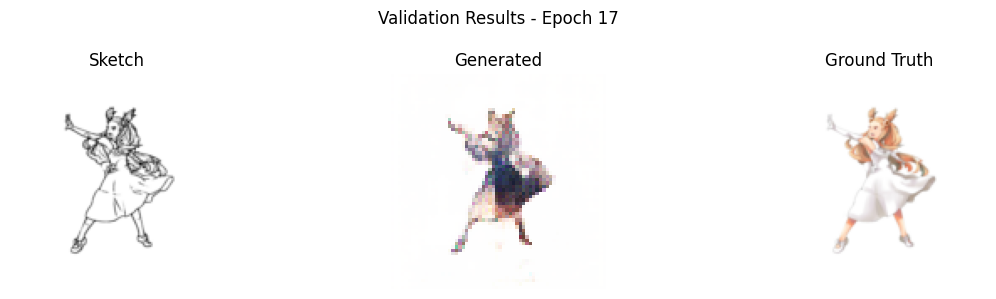

Epoch [18/20]: 100%|██████████| 1778/1778 [05:13<00:00,  5.67it/s, d_loss=1.06e-8, g_loss=31]



✅ Epoch [18/20] completed | D_Loss: 0.000000 | G_Loss: 27.788636 | Val_L1: 0.179328


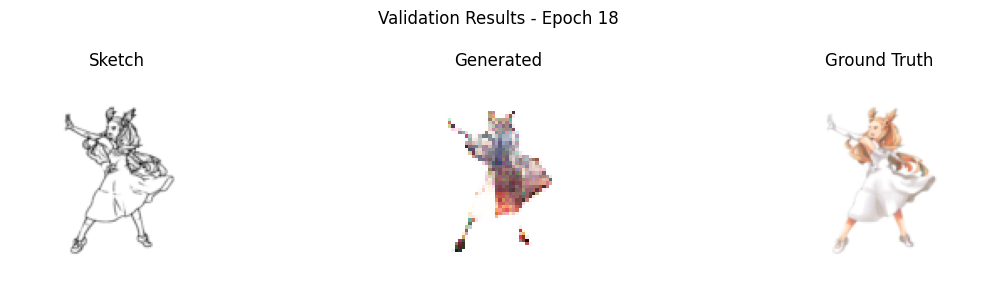

Epoch [19/20]: 100%|██████████| 1778/1778 [05:12<00:00,  5.69it/s, d_loss=6.42e-9, g_loss=29.7]



✅ Epoch [19/20] completed | D_Loss: 0.000000 | G_Loss: 28.492515 | Val_L1: 0.174107


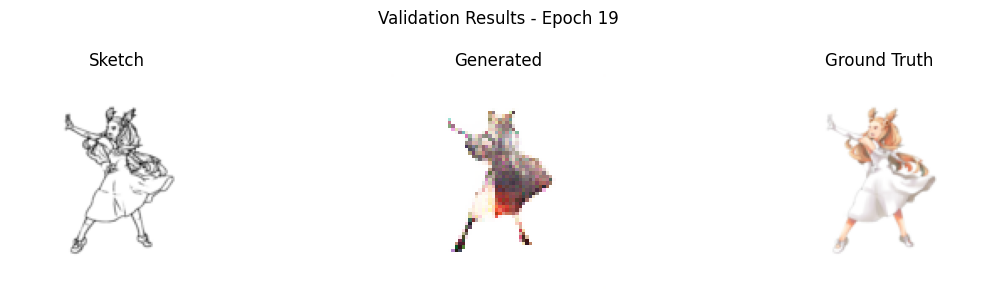

Epoch [20/20]: 100%|██████████| 1778/1778 [05:11<00:00,  5.70it/s, d_loss=7.59e-9, g_loss=28.6]



✅ Epoch [20/20] completed | D_Loss: 0.000000 | G_Loss: 29.215020 | Val_L1: 0.179581
💾 Checkpoints saved for epoch 20


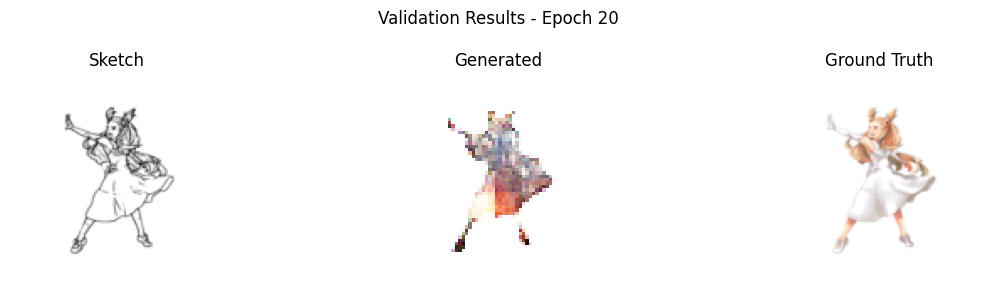

In [26]:
# =========================================
# FULL Pix2Pix GAN TRAINING LOOP WITH VALIDATION PREVIEW
# =========================================

import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from tqdm import tqdm
import matplotlib.pyplot as plt

# =====================================================
# STEP 1: Setup device and output directories
# =====================================================
torch.autograd.set_detect_anomaly(True)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("✅ Using device:", device)

os.makedirs("validation_results", exist_ok=True)

# =====================================================
# STEP 2: Initialize Models, Optimizers, and Losses
# =====================================================
gen  = UNetGenerator().to(device)
disc = PatchDiscriminator().to(device)

g_opt = optim.Adam(gen.parameters(), lr=2e-4, betas=(0.5, 0.999))
d_opt = optim.Adam(disc.parameters(), lr=2e-4, betas=(0.5, 0.999))

adv_criterion = nn.BCEWithLogitsLoss()
l1_criterion  = nn.L1Loss()
lambda_L1 = 100.0

# =====================================================
# STEP 3: Train + Validate Loop with Visualization
# =====================================================
EPOCHS = 20  # you can increase to 100+ for better results
train_g_losses, train_d_losses, val_l1_losses = [], [], []

for epoch in range(EPOCHS):
    gen.train()
    disc.train()
    epoch_g_loss, epoch_d_loss = 0.0, 0.0

    loop = tqdm(train_loader, desc=f"Epoch [{epoch+1}/{EPOCHS}]")

    # ---------------------
    # TRAINING PHASE
    # ---------------------
    for sketches, colors, _ in loop:
        sketches, colors = sketches.to(device), colors.to(device)

        # === Train Discriminator ===
        fake_colors = gen(sketches)
        fake_colors_resized = F.interpolate(
            fake_colors, size=sketches.shape[2:], mode='bilinear', align_corners=False
        )

        d_real = disc(sketches, colors)
        d_fake = disc(sketches, fake_colors_resized.detach())

        real_labels = torch.ones_like(d_real, device=device)
        fake_labels = torch.zeros_like(d_fake, device=device)

        d_loss_real = adv_criterion(d_real, real_labels)
        d_loss_fake = adv_criterion(d_fake, fake_labels)
        d_loss = (d_loss_real + d_loss_fake) / 2

        d_opt.zero_grad()
        d_loss.backward()
        d_opt.step()

        # === Train Generator ===
        g_fake = disc(sketches, fake_colors_resized)
        g_loss_adv = adv_criterion(g_fake, real_labels)
        g_loss_l1  = l1_criterion(fake_colors_resized, colors) * lambda_L1
        g_loss = g_loss_adv + g_loss_l1

        g_opt.zero_grad()
        g_loss.backward()
        g_opt.step()

        epoch_d_loss += d_loss.item()
        epoch_g_loss += g_loss.item()
        loop.set_postfix(d_loss=d_loss.item(), g_loss=g_loss.item())

    # =====================================================
    # VALIDATION PHASE (with L1 Loss)
    # =====================================================
    gen.eval()
    val_l1_loss = 0.0
    with torch.no_grad():
        for sketches, colors, _ in val_loader:
            sketches, colors = sketches.to(device), colors.to(device)
            fake_colors = gen(sketches)

            # Resize to match dimensions for L1 comparison
            fake_colors_resized = F.interpolate(
                fake_colors, size=colors.shape[2:], mode='bilinear', align_corners=False
            )
            val_l1_loss += l1_criterion(fake_colors_resized, colors).item()

    avg_d_loss = epoch_d_loss / len(train_loader)
    avg_g_loss = epoch_g_loss / len(train_loader)
    avg_val_l1 = val_l1_loss / len(val_loader)

    train_d_losses.append(avg_d_loss)
    train_g_losses.append(avg_g_loss)
    val_l1_losses.append(avg_val_l1)

    print(f"\n✅ Epoch [{epoch+1}/{EPOCHS}] completed | "
          f"D_Loss: {avg_d_loss:.6f} | G_Loss: {avg_g_loss:.6f} | Val_L1: {avg_val_l1:.6f}")

    # =====================================================
    # CHECKPOINT SAVING (every 10 epochs)
    # =====================================================
    if (epoch + 1) % 10 == 0:
        torch.save(gen.state_dict(), f"generator_epoch_{epoch+1}.pth")
        torch.save(disc.state_dict(), f"discriminator_epoch_{epoch+1}.pth")
        print(f"💾 Checkpoints saved for epoch {epoch+1}")

    # =====================================================
    # VALIDATION VISUALIZATION (every epoch)
    # =====================================================
    with torch.no_grad():
        sketches, colors, _ = next(iter(val_loader))
        sketches = sketches.to(device)
        fake_colors = gen(sketches).cpu()
        num_samples = min(4, sketches.shape[0])  # show up to 4 examples

        plt.figure(figsize=(12, num_samples * 3))
        for i in range(num_samples):
            # Sketch
            plt.subplot(num_samples, 3, 3*i + 1)
            plt.imshow(sketches[i][0].cpu() * 0.5 + 0.5, cmap='gray')
            plt.title("Sketch")
            plt.axis("off")

            # Generated color
            plt.subplot(num_samples, 3, 3*i + 2)
            plt.imshow(fake_colors[i].permute(1, 2, 0) * 0.5 + 0.5)
            plt.title("Generated")
            plt.axis("off")

            # Real color
            plt.subplot(num_samples, 3, 3*i + 3)
            plt.imshow(colors[i].permute(1, 2, 0).cpu() * 0.5 + 0.5)
            plt.title("Ground Truth")
            plt.axis("off")

        plt.suptitle(f"Validation Results - Epoch {epoch+1}", fontsize=12)
        plt.tight_layout()
        plt.savefig(f"validation_results/val_result_epoch_{epoch+1}.png")
        plt.show()
       # print(f"🖼️ Saved validation preview: validation_results/val_result_epoch_{epoch+1}.png")




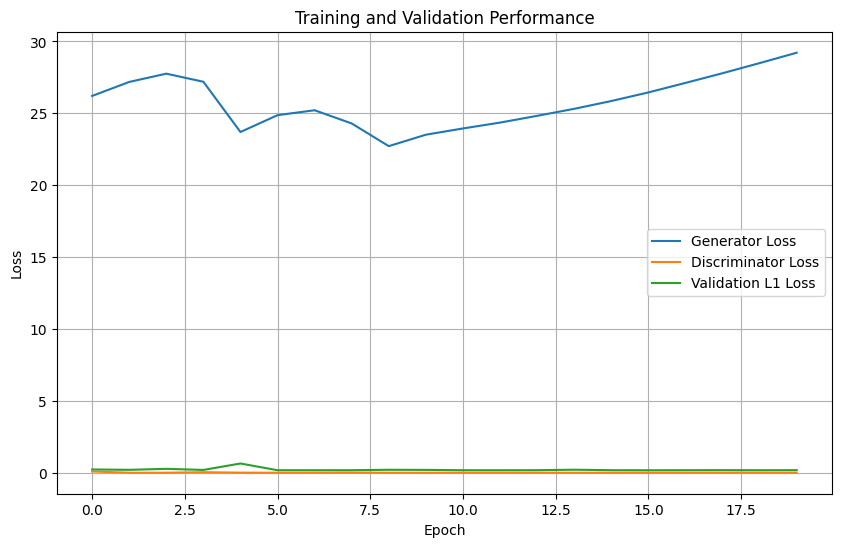

In [27]:
plt.figure(figsize=(10,6))
plt.plot(train_g_losses, label='Generator Loss')
plt.plot(train_d_losses, label='Discriminator Loss')
plt.plot(val_l1_losses, label='Validation L1 Loss')
plt.title("Training and Validation Performance")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

✅ Generator model loaded successfully!


Evaluating: 100%|██████████| 3545/3545 [01:05<00:00, 53.81it/s]



📊 Validation Metrics:
   • Average L1 Loss : 0.17958
   • Average PSNR    : 15.51 dB
   • Average SSIM    : 0.6644


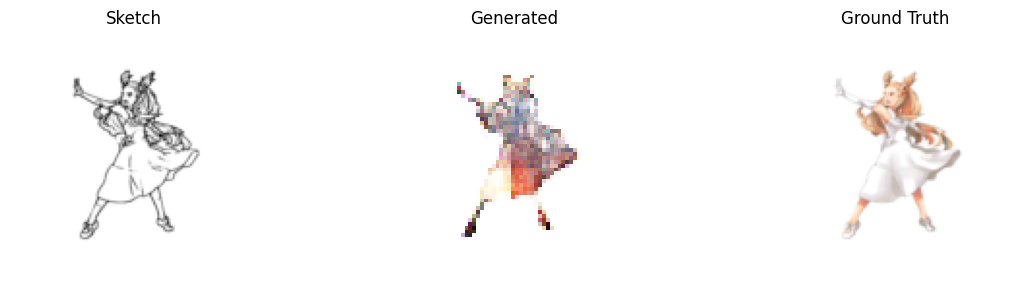

In [29]:
# =========================================
# EVALUATE TRAINED GENERATOR (SEPARATE CELL)
# =========================================
import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim

# -----------------------------------------
# Load trained generator model
# (Change filename if needed)
# -----------------------------------------
gen = UNetGenerator().to(device)
gen.load_state_dict(torch.load("generator_epoch_20.pth", map_location=device))
gen.eval()
print("✅ Generator model loaded successfully!")

# -----------------------------------------
# Prepare metrics
# -----------------------------------------
val_l1_loss = 0.0
val_psnr, val_ssim = 0.0, 0.0
num_images = 0
l1_criterion = torch.nn.L1Loss()

# -----------------------------------------
# Validation loop
# -----------------------------------------
with torch.no_grad():
    for sketches, colors, _ in tqdm(val_loader, desc="Evaluating"):
        sketches, colors = sketches.to(device), colors.to(device)
        fake_colors = gen(sketches)
        fake_colors_resized = F.interpolate(
            fake_colors, size=colors.shape[2:], mode='bilinear', align_corners=False
        )

        # --- L1 Loss ---
        val_l1_loss += l1_criterion(fake_colors_resized, colors).item()

        # --- PSNR and SSIM ---
        fake_np = fake_colors_resized.cpu().permute(0, 2, 3, 1).numpy()
        real_np = colors.cpu().permute(0, 2, 3, 1).numpy()

        for f, r in zip(fake_np, real_np):
            f = np.clip((f * 0.5 + 0.5), 0, 1)
            r = np.clip((r * 0.5 + 0.5), 0, 1)
            val_psnr += psnr(r, f, data_range=1.0)
            val_ssim += ssim(r, f, data_range=1.0, channel_axis=-1)
            num_images += 1

# -----------------------------------------
# Compute averages
# -----------------------------------------
avg_l1 = val_l1_loss / len(val_loader)
avg_psnr = val_psnr / num_images
avg_ssim = val_ssim / num_images

print(f"\n📊 Validation Metrics:")
print(f"   • Average L1 Loss : {avg_l1:.5f}")
print(f"   • Average PSNR    : {avg_psnr:.2f} dB")
print(f"   • Average SSIM    : {avg_ssim:.4f}")

# -----------------------------------------
# Show a few validation samples
# -----------------------------------------
sketches, colors, _ = next(iter(val_loader))
sketches = sketches.to(device)
colors = colors.to(device)
fake_colors = gen(sketches).cpu()

num_samples = min(4, sketches.shape[0])
plt.figure(figsize=(12, num_samples * 3))

for i in range(num_samples):
    # Sketch
    plt.subplot(num_samples, 3, 3*i + 1)
    plt.imshow(sketches[i][0].cpu().detach().numpy() * 0.5 + 0.5, cmap='gray')
    plt.title("Sketch")
    plt.axis("off")

    # Generated color
    plt.subplot(num_samples, 3, 3*i + 2)
    plt.imshow(fake_colors[i].detach().permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5)
    plt.title("Generated")
    plt.axis("off")

    # Real color
    plt.subplot(num_samples, 3, 3*i + 3)
    plt.imshow(colors[i].detach().permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5)
    plt.title("Ground Truth")
    plt.axis("off")

plt.tight_layout()
plt.show()


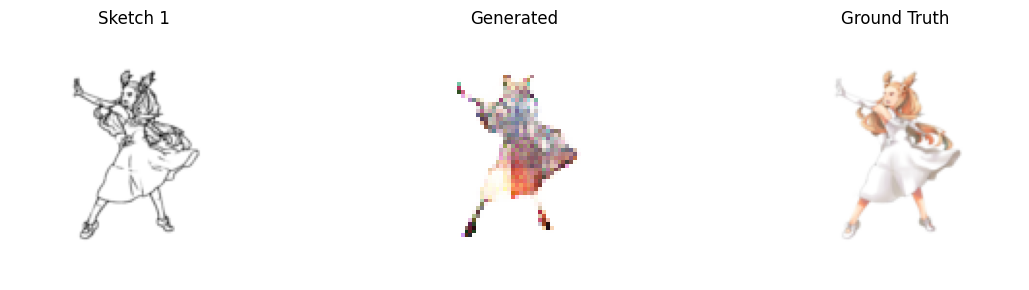

In [32]:
import torch
import matplotlib.pyplot as plt
import os

# Make sure the output folder exists
os.makedirs("validation_results", exist_ok=True)

# Set model to eval mode
gen.eval()

# Get one batch of validation data
sketches, colors, _ = next(iter(val_loader))
sketches, colors = sketches.to(device), colors.to(device)

# Generate outputs
with torch.no_grad():
    fake_colors = gen(sketches).cpu()

# Pick 5 samples max
num_samples = min(5, sketches.shape[0])

# Create plot
plt.figure(figsize=(12, num_samples * 3))

for i in range(num_samples):
    # 1️⃣ Sketch
    plt.subplot(num_samples, 3, 3*i + 1)
    plt.imshow(sketches[i][0].cpu().detach().numpy() * 0.5 + 0.5, cmap='gray')
    plt.title(f"Sketch {i+1}")
    plt.axis("off")

    # 2️⃣ Generated color
    plt.subplot(num_samples, 3, 3*i + 2)
    plt.imshow(fake_colors[i].detach().permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5)
    plt.title("Generated")
    plt.axis("off")

    # 3️⃣ Ground truth
    plt.subplot(num_samples, 3, 3*i + 3)
    plt.imshow(colors[i].detach().permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5)
    plt.title("Ground Truth")
    plt.axis("off")

plt.tight_layout()
plt.savefig("validation_results/val_preview_5samples.png", bbox_inches="tight")
plt.show()




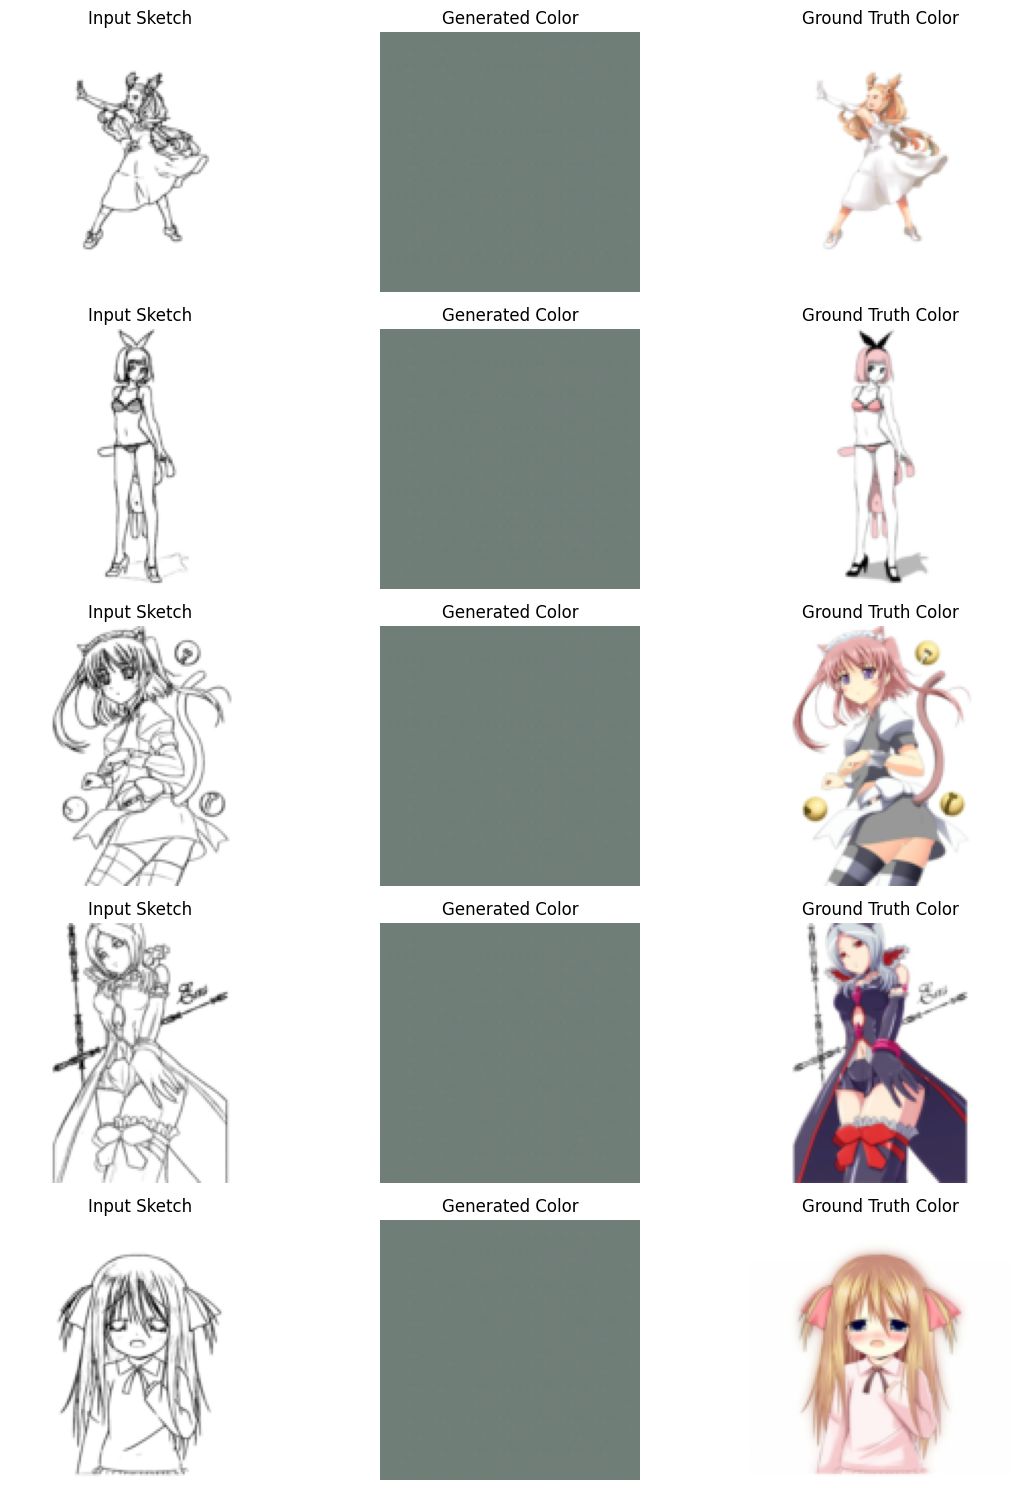

In [33]:
import matplotlib.pyplot as plt

if len(val_results) == 0:
    print("⚠️ No validation results found. Run validation first.")
else:
    num_examples = 5  # how many to show
    plt.figure(figsize=(12, num_examples * 3))

    shown = 0
    for batch_idx, (sketches, colors, fakes) in enumerate(val_results):
        batch_size = sketches.shape[0]
        for j in range(batch_size):
            if shown >= num_examples:
                break

            sketch = sketches[j][0].numpy() * 0.5 + 0.5
            fake = fakes[j].permute(1, 2, 0).numpy() * 0.5 + 0.5
            real = colors[j].permute(1, 2, 0).numpy() * 0.5 + 0.5

            plt.subplot(num_examples, 3, 3*shown + 1)
            plt.imshow(sketch, cmap='gray')
            plt.title("Input Sketch")
            plt.axis("off")

            plt.subplot(num_examples, 3, 3*shown + 2)
            plt.imshow(fake)
            plt.title("Generated Color")
            plt.axis("off")

            plt.subplot(num_examples, 3, 3*shown + 3)
            plt.imshow(real)
            plt.title("Ground Truth Color")
            plt.axis("off")

            shown += 1
        if shown >= num_examples:
            break

    plt.tight_layout()
    plt.show()


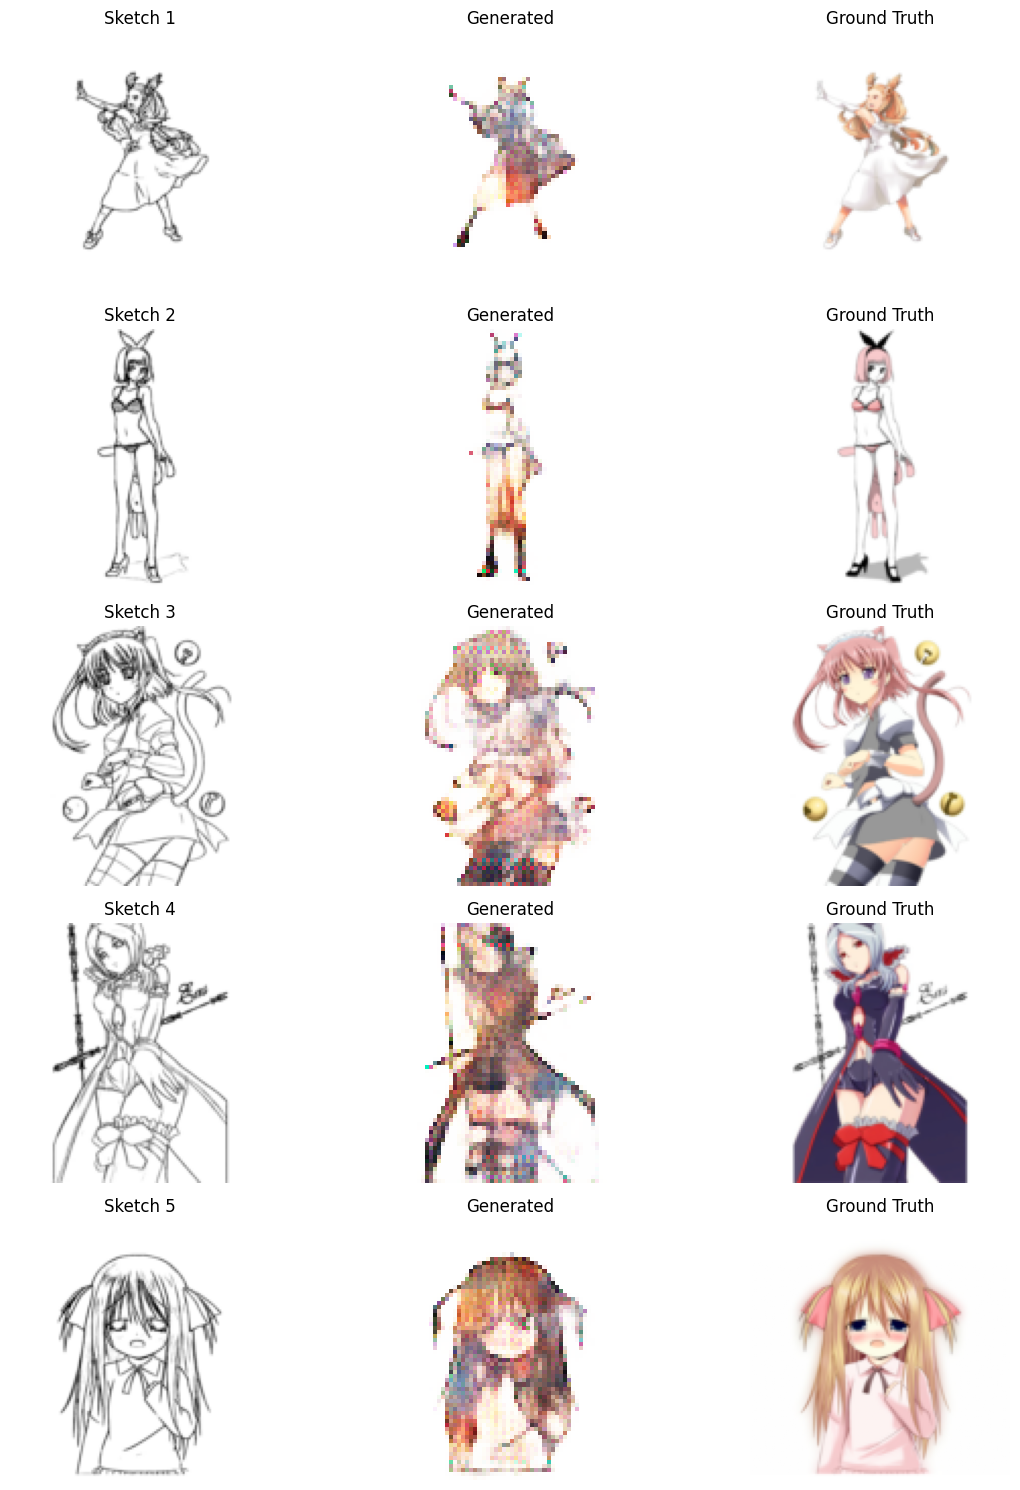

In [35]:
import torch
import matplotlib.pyplot as plt
import os

# Ensure output folder exists
os.makedirs("validation_results", exist_ok=True)

gen.eval()
device = "cuda" if torch.cuda.is_available() else "cpu"

# ---------------------------
# Collect 5 distinct samples
# ---------------------------
collected_samples = []
with torch.no_grad():
    for sketches, colors, _ in val_loader:
        sketches, colors = sketches.to(device), colors.to(device)
        fake_colors = gen(sketches)
        for i in range(sketches.shape[0]):
            collected_samples.append((
                sketches[i].cpu(),
                colors[i].cpu(),
                fake_colors[i].cpu()
            ))
            if len(collected_samples) >= 5:
                break
        if len(collected_samples) >= 5:
            break

# ---------------------------
# Plot the 5 samples
# ---------------------------
plt.figure(figsize=(12, 15))

for idx, (sketch, real, fake) in enumerate(collected_samples):
    # Sketch
    plt.subplot(5, 3, 3*idx + 1)
    plt.imshow(sketch[0].numpy() * 0.5 + 0.5, cmap='gray')
    plt.title(f"Sketch {idx+1}")
    plt.axis("off")

    # Generated
    plt.subplot(5, 3, 3*idx + 2)
    plt.imshow(fake.detach().permute(1, 2, 0).numpy() * 0.5 + 0.5)
    plt.title("Generated")
    plt.axis("off")

    # Ground Truth
    plt.subplot(5, 3, 3*idx + 3)
    plt.imshow(real.detach().permute(1, 2, 0).numpy() * 0.5 + 0.5)
    plt.title("Ground Truth")
    plt.axis("off")

plt.tight_layout()
plt.savefig("validation_results/val_5samples_across_dataset.png", bbox_inches="tight")
plt.show()




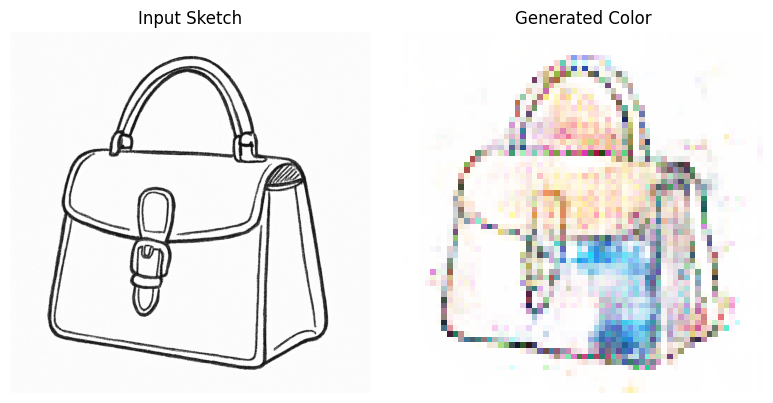

In [36]:
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

# ----------------------------
# 1️⃣ Load and preprocess your sketch
# ----------------------------
def load_sketch(image_path):
    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])  # same normalization used during training
    ])
    img = Image.open(image_path).convert("L")  # grayscale
    return transform(img).unsqueeze(0)  # add batch dimension

# ----------------------------
# 2️⃣ Generate colorized image
# ----------------------------
def colorize_sketch(model, sketch_tensor, device="cuda"):
    model.eval()
    with torch.no_grad():
        sketch_tensor = sketch_tensor.to(device)
        fake_color = model(sketch_tensor)
        fake_color = fake_color.cpu().squeeze(0)  # remove batch dim
        fake_color = (fake_color * 0.5 + 0.5).clamp(0, 1)  # denormalize to [0,1]
    return fake_color

# ----------------------------
# 3️⃣ Visualize result
# ----------------------------
def show_colorization(sketch_path, model, device="cuda"):
    sketch_tensor = load_sketch(sketch_path)
    fake_color = colorize_sketch(model, sketch_tensor, device)

    # Display results
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(Image.open(sketch_path).convert("L"), cmap="gray")
    plt.title("Input Sketch")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(fake_color.permute(1, 2, 0).numpy())
    plt.title("Generated Color")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# ----------------------------
# 4️⃣ Try with your own sketch
# ----------------------------
sketch_path = "/content/sketch_2.png"  # 🔁 change to your uploaded file path
show_colorization(sketch_path, gen, device)


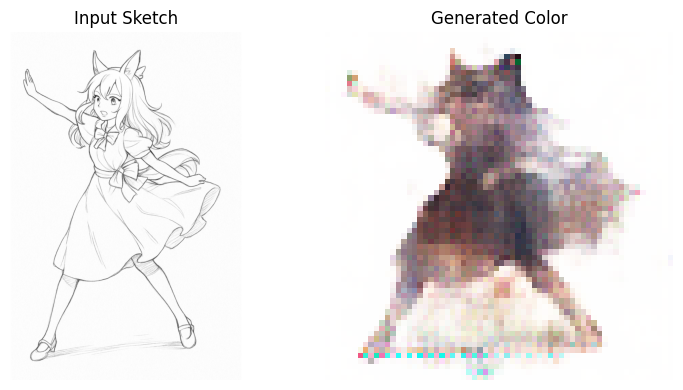

In [37]:
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

# ----------------------------
# 1️⃣ Load and preprocess your sketch
# ----------------------------
def load_sketch(image_path):
    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])  # same normalization used during training
    ])
    img = Image.open(image_path).convert("L")  # grayscale
    return transform(img).unsqueeze(0)  # add batch dimension

# ----------------------------
# 2️⃣ Generate colorized image
# ----------------------------
def colorize_sketch(model, sketch_tensor, device="cuda"):
    model.eval()
    with torch.no_grad():
        sketch_tensor = sketch_tensor.to(device)
        fake_color = model(sketch_tensor)
        fake_color = fake_color.cpu().squeeze(0)  # remove batch dim
        fake_color = (fake_color * 0.5 + 0.5).clamp(0, 1)  # denormalize to [0,1]
    return fake_color

# ----------------------------
# 3️⃣ Visualize result
# ----------------------------
def show_colorization(sketch_path, model, device="cuda"):
    sketch_tensor = load_sketch(sketch_path)
    fake_color = colorize_sketch(model, sketch_tensor, device)

    # Display results
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(Image.open(sketch_path).convert("L"), cmap="gray")
    plt.title("Input Sketch")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(fake_color.permute(1, 2, 0).numpy())
    plt.title("Generated Color")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# ----------------------------
# 4️⃣ Try with your own sketch
# ----------------------------
sketch_path = "/content/sketch_1.png"  # 🔁 change to your uploaded file path
show_colorization(sketch_path, gen, device)


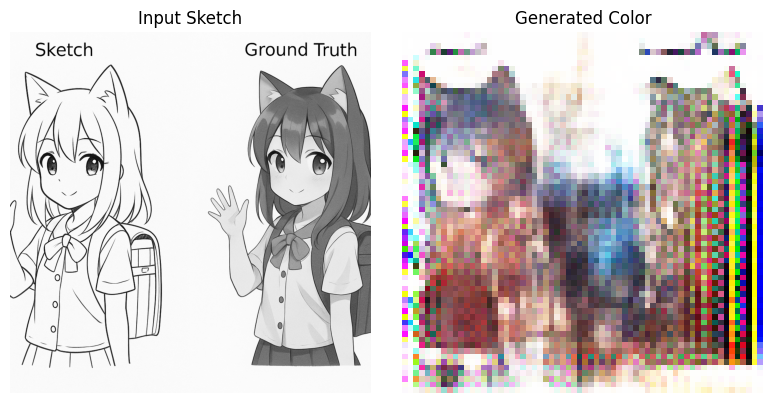

In [38]:
import torch
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt

# ----------------------------
# 1️⃣ Load and preprocess your sketch
# ----------------------------
def load_sketch(image_path):
    transform = transforms.Compose([
        transforms.Resize((128, 128)),
        transforms.ToTensor(),
        transforms.Normalize([0.5], [0.5])  # same normalization used during training
    ])
    img = Image.open(image_path).convert("L")  # grayscale
    return transform(img).unsqueeze(0)  # add batch dimension

# ----------------------------
# 2️⃣ Generate colorized image
# ----------------------------
def colorize_sketch(model, sketch_tensor, device="cuda"):
    model.eval()
    with torch.no_grad():
        sketch_tensor = sketch_tensor.to(device)
        fake_color = model(sketch_tensor)
        fake_color = fake_color.cpu().squeeze(0)  # remove batch dim
        fake_color = (fake_color * 0.5 + 0.5).clamp(0, 1)  # denormalize to [0,1]
    return fake_color

# ----------------------------
# 3️⃣ Visualize result
# ----------------------------
def show_colorization(sketch_path, model, device="cuda"):
    sketch_tensor = load_sketch(sketch_path)
    fake_color = colorize_sketch(model, sketch_tensor, device)

    # Display results
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(Image.open(sketch_path).convert("L"), cmap="gray")
    plt.title("Input Sketch")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(fake_color.permute(1, 2, 0).numpy())
    plt.title("Generated Color")
    plt.axis("off")

    plt.tight_layout()
    plt.show()

# ----------------------------
# 4️⃣ Try with your own sketch
# ----------------------------
sketch_path = "/content/sketch_3.png"  # 🔁 change to your uploaded file path
show_colorization(sketch_path, gen, device)
